<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">
<h1 style="color:#e94560; text-align:center;"> 💠 Part 4 — Clustering</h1>
<h3 style="color:#ffffff; text-align:center;">Athlete Performance Score Prediction — DS301</h3>
<p style="color:#a8a8b3; text-align:center;">
Dataset: <a href="https://www.kaggle.com/datasets/zara2099/athlete-performance-evaluation-dataset" style="color:#00b4d8;">Kaggle — Athlete Performance Evaluation</a><br>
K-Means, DBSCAN and Agglomerative Clustering </p>
</div>

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📦 1. Load and preprocessing </h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load all required libraries and explore your dataset</p>
</div>

In [ ]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# 1. Load and explore your dataset [file:1]
df = pd.read_csv('athlete_performance_dataset.csv')

df.describe()

,heart_rate,oxygen_saturation,respiration_rate,body_temperature,hydration_level,speed,acceleration,endurance_score,agility_score,reaction_time,workload,fatigue_index,feature_1,feature_2,feature_3,feature_4,feature_5,performance_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,121.184635,95.070173,20.048115,37.471125,64.587373,6.489251,2.719890,48.237062,48.649669,323.878244,555.122566,0.505252,-0.005171,-0.012750,0.009786,-0.018017,0.024247,0.496677
std,39.438544,2.921899,5.813484,0.859468,20.076696,2.024364,1.303801,28.491440,28.223452,98.753631,257.807705,0.296171,0.575640,0.587821,0.579501,0.581643,0.575905,0.110039
min,55.625323,90.032183,10.000233,36.001960,30.002150,3.043287,0.506428,0.024100,0.024293,150.018489,100.848738,0.000158,-0.997593,-0.997333,-0.997360,-0.999381,-0.999495,0.183052
25%,86.856391,92.410743,15.227020,36.725702,47.148180,4.745660,1.580997,23.598929,24.938371,242.450445,327.367871,0.253438,-0.504282,-0.530334,-0.490641,-0.526275,-0.458952,0.419186
50%,122.068996,95.187339,20.012278,37.452838,64.621867,6.432820,2.680894,48.399070,47.870095,323.315379,555.729507,0.494452,-0.020320,-0.035139,0.001929,-0.015313,0.046046,0.495015
75%,155.483144,97.604651,25.182071,38.212622,81.799542,8.178962,3.904090,71.446625,71.590497,407.676032,781.031926,0.773658,0.506406,0.504174,0.536983,0.493572,0.500388,0.569606
max,189.961886,99.994137,29.956417,38.998673,99.842457,9.995452,4.997573,99.890470,99.601278,499.826816,999.705885,0.999335,0.997397,0.997690,0.999610,0.999850,0.998299,0.808333


In [ ]:
# 2.Drop columns that must NOT be used for clustering [file:1]
df_clust = df.drop(columns=["timestamp", "performance_score", "performance_category"])

numeric_cols = df_clust.columns  # all remaining are numeric
X = df_clust.values

In [5]:
# 3. Standardize all features (critical rule) [file:1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA to 2 components for visualisation only [file:1]
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (1000, 17)
PCA shape: (1000, 2)


<div style="background-color:#533483; padding:15px; border-radius:10px; border-left:6px solid #ffcc00;">
<h2 style="color:#ffffff; margin:0;">🔍 2. K-Means: Elbow and Silhouette</h2>
<p style="color:#f0e6ff; margin:5px 0 0 0;">Plots and best values</p>
</div>

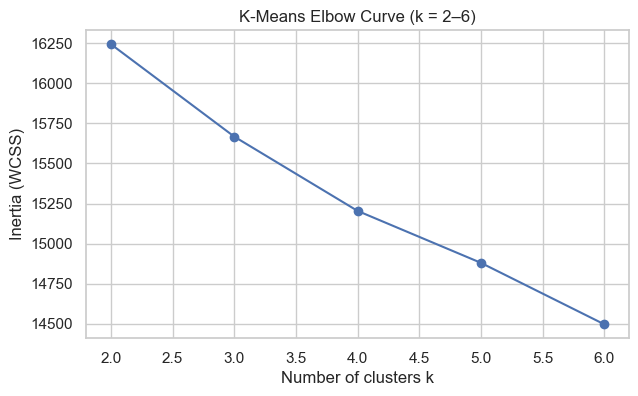

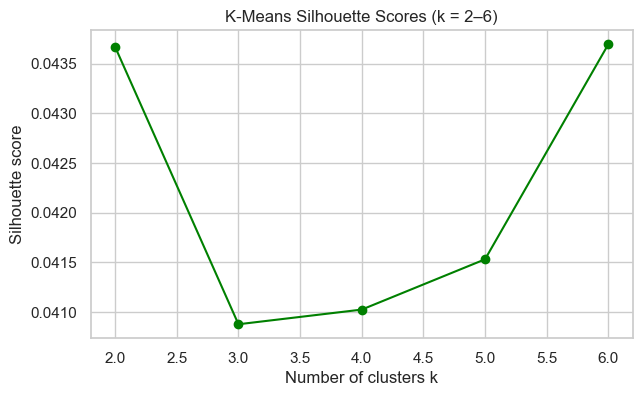

k, inertia, silhouette:
(2, 16243.388989087565, np.float64(0.0436670141885112))
(3, 15667.44117787063, np.float64(0.040878828962573395))
(4, 15204.394390713958, np.float64(0.04102627133632914))
(5, 14880.708920234214, np.float64(0.04153181252723349))
(6, 14497.72514160514, np.float64(0.04369431262960278))
Best k in this range (by silhouette): 6


In [38]:
sns.set(style="whitegrid", context="notebook")

# 2. K-Means: Elbow curve (k = 2 to 6) and Silhouette scores (focused search)
inertias = []
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)  # use full scaled features
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow curve (Inertia / WCSS)
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (WCSS)")
plt.title("K-Means Elbow Curve (k = 2–6)")
plt.show()

# Silhouette scores for each k
plt.figure(figsize=(7, 4))
plt.plot(k_values, sil_scores, marker="o", color="green")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Scores (k = 2–6)")
plt.show()

# Show the values and best k
results = list(zip(k_values, inertias, sil_scores))
print("k, inertia, silhouette:")
for r in results:
    print(r)

best_k = k_values[int(np.argmax(sil_scores))]
print("Best k in this range (by silhouette):", best_k)

<div style="background-color:#065535; padding:15px; border-radius:10px; border-left:6px solid #00ff88;">
<h2 style="color:#ffffff; margin:0;">📊 3. K-Means: Final model with chosen k</h2>
<p style="color:#b8ffdc; margin:5px 0 0 0;">Optimal k, K-Means silhouette and K-Means inertia</p>
</div>

In [41]:
# 8 . Fit final K-Means model with chosen k (here k = 8) [file:1]
optimal_k = 6  # chosen based on silhouette and inertia trends

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init="auto")
kmeans_labels = kmeans_final.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

print("Optimal k:", optimal_k)
print("K-Means silhouette:", kmeans_sil)
print("K-Means inertia:", kmeans_final.inertia_)

Optimal k: 6
K-Means silhouette: 0.04369431262960278
K-Means inertia: 14497.72514160514


<div style="background-color:#c94b4b; padding:15px; border-radius:10px; border-left:6px solid #ffffff;">
<h2 style="color:#ffffff; margin:0;">⚙️ 4. K-Means: PCA scatter plot</h2>
<p style="color:#ffe0e0; margin:5px 0 0 0;">Clusters in PCA</p>
</div>

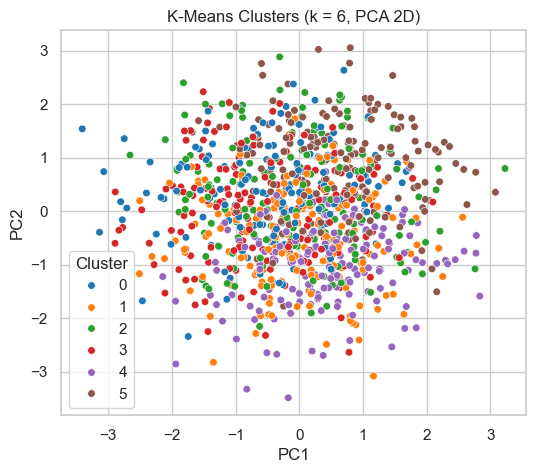

In [42]:
# 9. Visualise K-Means clusters in PCA-reduced 2D space [file:1]
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="tab10",
    s=30
)
plt.title(f"K-Means Clusters (k = {optimal_k}, PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

<div style="background-color:#7b2d8b; padding:15px; border-radius:10px; border-left:6px solid #ff9ef5;">
<h2 style="color:#ffffff; margin:0;">🤖 5. DBSCAN: parameter search and clustering</h2>
<p style="color:#f9d4ff; margin:5px 0 0 0;">Data Frame testing different hyperparameters for DBSCAN </p>
</div>

In [ ]:
# 10. DBSCAN: grid search over eps and min_samples (wider eps range) [file:1]
eps_values = [1.5, 2.0, 2.5, 3.0]   # widened compared to 0.3–1.3
min_samples_values = [3, 5, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Only compute silhouette if at least 2 clusters and not all noise
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan
        
        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil
        })

dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df

,eps,min_samples,n_clusters,n_noise,silhouette
0,1.5,3,0,1000,NaN
1,1.5,5,0,1000,NaN
2,1.5,10,0,1000,NaN
3,2.0,3,0,1000,NaN
4,2.0,5,0,1000,NaN
5,2.0,10,0,1000,NaN
6,2.5,3,2,994,-0.136703
7,2.5,5,0,1000,NaN
8,2.5,10,0,1000,NaN
9,3.0,3,37,796,-0.192334


<div style="background-color:#b5451b; padding:15px; border-radius:10px; border-left:6px solid #ffdd57;">
<h2 style="color:#ffffff; margin:0;">📉 Step 6 – Final DBSCAN model + PCA scatter</h2>
<p style="color:#fff3b0; margin:5px 0 0 0;">Visualise DBSCAN clusters </p>
</div>

In [21]:
# 12. Fit final DBSCAN model with chosen parameters
best_eps = 2.5
best_min_samples = 3

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

dbscan_n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
dbscan_n_noise = list(dbscan_labels).count(-1)

if dbscan_n_clusters >= 2:
    dbscan_sil = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_sil = np.nan

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Clusters found:", dbscan_n_clusters)
print("Noise points:", dbscan_n_noise)
print("Silhouette score:", dbscan_sil)

Best eps: 2.5
Best min_samples: 3
Clusters found: 2
Noise points: 994
Silhouette score: -0.13670255503861173


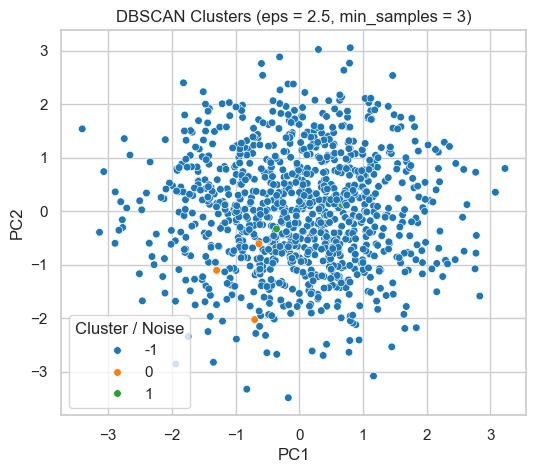

In [22]:
# 13. Visualise DBSCAN clusters in PCA 2D
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=dbscan_labels,
    palette="tab10",
    s=30
)
plt.title(f"DBSCAN Clusters (eps = {best_eps}, min_samples = {best_min_samples})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster / Noise")
plt.show()

<div style="background-color:#0d3b66; padding:15px; border-radius:10px; border-left:6px solid #ffd166;">
<h2 style="color:#ffffff; margin:0;">🔧 Step 7 – Agglomerative: dendrogram</h2>
<p style="color:#ffe8a3; margin:5px 0 0 0;">Agglomerative Clustering: dendrogram (ward linkage)</p>
</div>

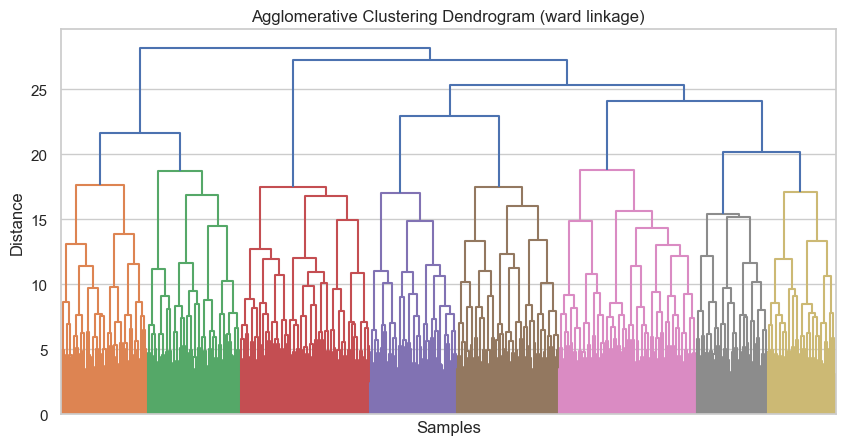

In [23]:
# Step 14. Agglomerative Clustering: dendrogram (ward linkage)
X_for_dendro = X_scaled  # or a sample if needed

linked = sch.linkage(X_for_dendro, method="ward")

plt.figure(figsize=(10, 5))
sch.dendrogram(linked, no_labels=True)
plt.title("Agglomerative Clustering Dendrogram (ward linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

<div style="background-color:#1a472a; padding:15px; border-radius:10px; border-left:6px solid #52b788;">
<h2 style="color:#ffffff; margin:0;">🎯 Step 8 – Compare linkage methods</h2>
<p style="color:#b7e4c7; margin:5px 0 0 0;">Compare linkage methods (ward, complete, average) and best linkage (ward)</p>
</div>

In [ ]:

# 15. Compare linkage methods (ward, complete, average)
linkage_methods = ["ward", "complete", "average"]
agg_results = []

n_clusters_agg = 6  # same number of clusters as K-Means, for easier comparison

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage=method)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    agg_results.append({
        "linkage": method,
        "n_clusters": n_clusters_agg,
        "silhouette": sil
    })

agg_df = pd.DataFrame(agg_results)
agg_df

,linkage,n_clusters,silhouette
0,ward,6,0.012592
1,complete,6,0.000698
2,average,6,-0.037899


In [25]:
# 16. Fit final Agglomerative model with best linkage (ward)
best_linkage = "ward"
n_clusters_agg = 6  # same as before

agg_final = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage=best_linkage)
agg_labels = agg_final.fit_predict(X_scaled)
agg_sil = silhouette_score(X_scaled, agg_labels)

print("Best linkage:", best_linkage)
print("Agglomerative clusters:", n_clusters_agg)
print("Silhouette:", agg_sil)

Best linkage: ward
Agglomerative clusters: 6
Silhouette: 0.012592435137633397


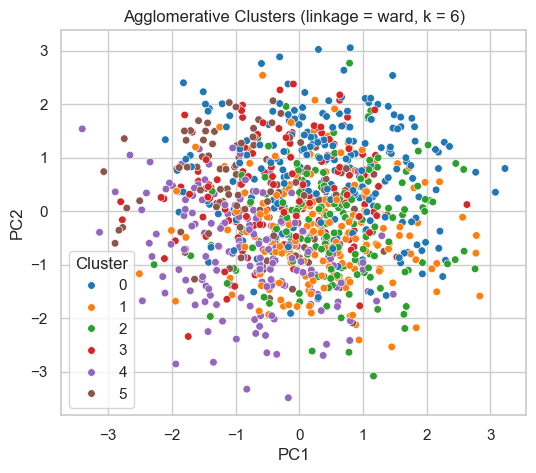

In [26]:
#17. Visualise Agglomerative clusters in PCA 2D
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=agg_labels,
    palette="tab10",
    s=30
)
plt.title(f"Agglomerative Clusters (linkage = {best_linkage}, k = {n_clusters_agg})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

<div style="background-color:#212529; padding:15px; border-radius:10px; border-left:6px solid #adb5bd;">
<h2 style="color:#ffffff; margin:0;">⭐ Step 9 – Comparison table (K-Means, DBSCAN, Agglomerative)</h2>
<p style="color:#ced4da; margin:5px 0 0 0;"></p>
</div>

In [28]:
# 18 . Comparison table across clustering algorithms
comparison = pd.DataFrame([
    {
        "Algorithm": "K-Means",
        "Clusters": optimal_k,          # 6 in your case
        "Silhouette": kmeans_sil,       # from Step 3
        "Key observations": "Clusters weak and overlapping in PCA; treats data as 6 soft performance profiles."
    },
    {
        "Algorithm": "DBSCAN",
        "Clusters": dbscan_n_clusters,  # e.g. 2
        "Silhouette": dbscan_sil,       # negative or NaN
        "Key observations": f"Most points labelled as noise ({dbscan_n_noise}); no clear dense groups."
    },
    {
        "Algorithm": "Agglomerative",
        "Clusters": n_clusters_agg,     # 6
        "Silhouette": agg_sil,          # ≈ 0.013
        "Key observations": f"Similar overlap to K-Means; dendrogram shows gradual merges (linkage={best_linkage})."
    }
])

comparison

,Algorithm,Clusters,Silhouette,Key observations
0,K-Means,6,0.043694,Clusters weak and overlapping in PCA; treats d...
1,DBSCAN,2,-0.136703,Most points labelled as noise (994); no clear ...
2,Agglomerative,6,0.012592,Similar overlap to K-Means; dendrogram shows g...
